In [1]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('../src')))

In [2]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocess import build_dataset
from utils import predict_movie_rating_with_prob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

['user_id', 'movie_id', 'rating', 'timestamp', 'labels', 'age', 'gender', 'occupation', 'zip_code', 'title', 'release_date', 'video_release_date', 'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'FilmNoir', 'Horror', 'Musical', 'Mystery', 'Romance', 'SciFi', 'Thriller', 'War', 'Western']


In [3]:
with open('naivebayes_model.pkl', 'rb') as f:
    df_train = pickle.load(f)

In [4]:
df_all = build_dataset()
df_all['actual_label'] = (df_all['rating'] >= 4.0).astype(int)

_, df_test = train_test_split(df_all, test_size=0.2, random_state=42)
print(f"-> Regen {len(df_test)} data columns.")

df_sample = df_test.sample(n=300, random_state=42)
y_true = df_sample['actual_label'].tolist()

-> Tái tạo thành công tập Test độc lập với 18994 dòng dữ liệu.


In [5]:
# Chạy dự đoán thần tốc qua 1 dòng code bằng cách unpack zip
y_pred, y_prob = zip(*[predict_movie_rating_with_prob(r.user_id, r.movie_id, df_train) for r in df_sample.itertuples()])

In [6]:
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f} | Precision: {precision_score(y_true, y_pred):.4f} | Recall: {recall_score(y_true, y_pred):.4f} | F1: {f1_score(y_true, y_pred):.4f}")

Accuracy: 0.7300 | Precision: 0.7263 | Recall: 0.8263 | F1: 0.7731


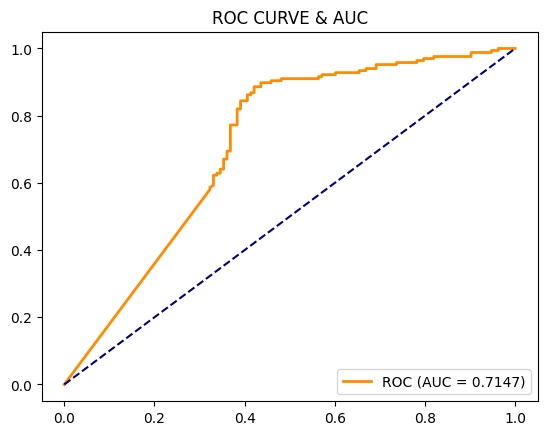

In [7]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc(fpr, tpr):.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC CURVE & AUC')
plt.legend(loc="lower right")
plt.show()

Text(0.5, 1.0, 'CONFUSION MATRIX')

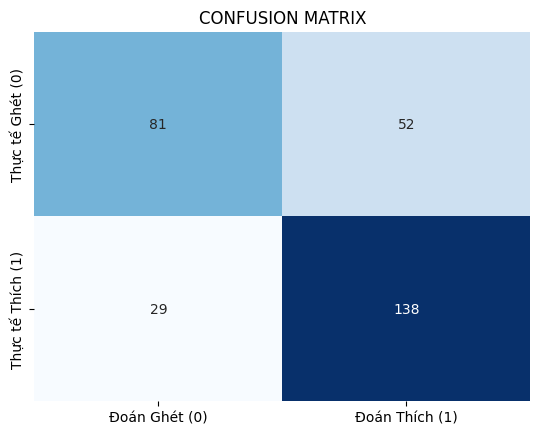

In [8]:
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Đoán Ghét (0)', 'Đoán Thích (1)'], yticklabels=['Thực tế Ghét (0)', 'Thực tế Thích (1)'])
plt.title('CONFUSION MATRIX')